Model Notebook

This is a notebook for model in age gender detector. Here we will extract the data,train it and fit it into our model, and will evaluate our results and optimize the model for better results

Import the necessary libraries

In [1]:
pip install tensorflow

In [2]:
pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
import cv2
import numpy as np
from matplotlib import pyplot as plt 
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dense,MaxPool2D,Conv2D
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input,Activation,Add
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam,Adagrad,Adadelta,Adamax,RMSprop

#Extract data from the dataset

In [4]:
fldr=r"C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace"

In [5]:
import os 
files=os.listdir(fldr)

In [6]:
import cv2

#create list of images from the dataset

In [7]:
ages=[]
genders=[]
images=[]

for fle in files:
    age=int(fle.split('_')[0])
    gender=int(fle.split('_')[1])
    total=fldr+'/'+fle
    print(total)
    
    image=cv2.imread(total)

    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image=cv2.resize(image,(48,48))
    images.append(image)

C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_0_0_20170112213500903.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_0_0_20170112215240346.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_0_20170110183726390.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_0_20170112213001988.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_0_20170112213303693.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_0_20170112215032192.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_0_20170117195420803.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_0_20170119212053665.jpg.chip.jpg
C:\Users\Sanskruti\OneDrive\Documents\agegenderdetector\archive\UTKFace/100_1_2_20170105174847679.jpg.chip.jpg
C

#create list of age and gender from the dataset

In [8]:
for fle in files:
    age=int(fle.split('_')[0])
    gender=int(fle.split('_')[1])
    ages.append(age)
    genders.append(gender)

#viewing a sample

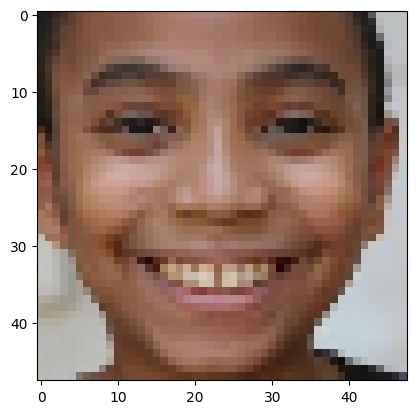

In [9]:
plt.imshow(images[87])

In [10]:
print(ages[87])


10


In [11]:
print(genders[87])

0


#saving the image array,ages array and genders array in the sstem

In [12]:
images_f=np.array(images)
ages_f=np.array(ages)
genders_f=np.array(genders)

In [13]:
np.save(fldr+'image.npy',images_f)
np.save(fldr+'ages.npy',ages_f)
np.save(fldr+'genders.npy',genders_f)

#finding the number of male and female samples respectively

In [14]:
values,counts=np.unique(genders_f,return_counts=True)
print(counts)

[12391 11317]


#plotting the number of male and female samoles

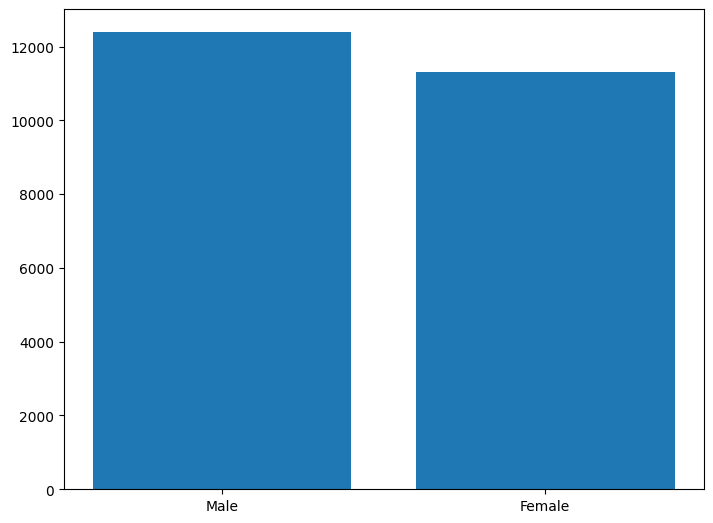

In [15]:
fig=plt.figure()
ax=fig.add_axes([0,0,1,1])
gender=['Male','Female']
values=[12391,11317]
ax.bar(gender,values)
plt.show()

##Finding the number of samples n each age

In [16]:
values,counts=np.unique(ages_f,return_counts=True)
print(counts)

[1123  482  289  273  196  131  139  263  166  156   65  130   81  157
  177  247  158  262   98  284  346  395  426  859  734 2197  615  918
  570  724  350  664  143  409  880  483  293  325  266  526  132  266
  157  100  440  153  170  153  148  381  138  232  241  353  268  236
   97  271   82  293  161  125  103   50  259   77   94  100   56  147
   33   98   63   32  148   58   28   69   23  133   22   40   18   24
  155   35   10   34   33   82    2   13    5    9   17    9   11    2
    1    5    5    1    3    4]


converting age counts to list

In [17]:
val=values.tolist()
cnt=counts.tolist()

#plotting the samples agewise

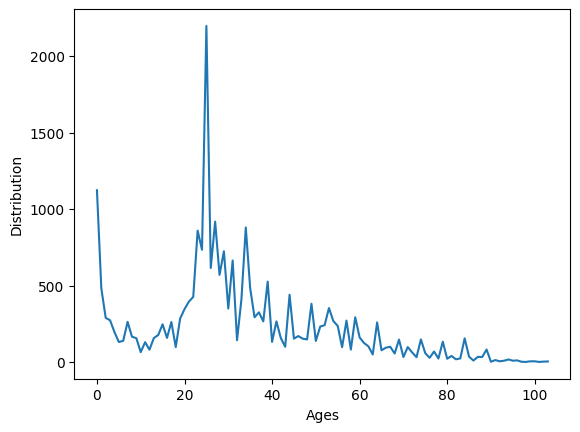

In [18]:
plt.plot(counts)
plt.xlabel('Ages')
plt.ylabel('Distribution')
plt.show()

#DEfining Labels for output

In [19]:
labels=[]
i=0
while i<len(ages):
    label=[]
    label.append(ages[i])
    label.append(genders[i])
    labels.append(label)
    i=i+1

##creating another list of images from existing one

In [20]:
images_f_2=images_f/255

In [21]:
images_f_2.shape

(23708, 48, 48, 3)

In [22]:
labels_f=np.array(labels)

##Splitting thr data into test and train

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(images_f_2,labels_f,test_size=0.25)

In [25]:
Y_train[0:5]

array([[45,  0],
       [ 8,  1],
       [42,  0],
       [58,  0],
       [30,  0]])

##Splitting Y_train and Y_testt  further

In [26]:
Y_train_2=[Y_train[:,1],Y_train[:,0]]
Y_test_2=[Y_test[:,1],Y_test[:,0]]

In [27]:
Y_train_2[0][0:5]

array([0, 1, 0, 0, 0])

In [28]:
Y_train_2[1][0:5]

array([45,  8, 42, 58, 30])

#defining the model

In [29]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


In [30]:
def Convolution(input_tensor,filters):
    x=Conv2D(filters=filters,kernel_size=(3,3),padding="same",strides=(1,1),kernel_regularizer=l2(0.001))(input_tensor)
    x=Dropout(0.1)(x)
    x=Activation('relu')(x)
    return x

In [31]:
def model(input_shape):
    inputs=Input((input_shape))
    conv_1=Convolution(inputs,32)
    maxp_1=MaxPooling2D(pool_size=(2,2))(conv_1)
    conv_2=Convolution(maxp_1,64)
    maxp_2=MaxPooling2D(pool_size=(2,2))(conv_2)
    conv_3=Convolution(maxp_2,128)
    maxp_3=MaxPooling2D(pool_size=(2,2))(conv_3)
    conv_4=Convolution(maxp_3,256)
    maxp_4=MaxPooling2D(pool_size=(2,2))(conv_4)
    flatten=Flatten()(maxp_4)
    dense_1=Dense(64,activation='relu')(flatten)
    dense_2=Dense(64,activation='relu')(flatten)
    drop_1=Dropout(0.2)(dense_1)
    drop_2=Dropout(0.2)(dense_2)
    output_1=Dense(1,activation='sigmoid',name='sex_out')(drop_1)
    output_2=Dense(1,activation='relu',name='age_out')(drop_2)
    model=Model(inputs=[inputs],outputs=[output_1,output_2])
    model.compile(loss=["binary_crossentropy","mean_squared_error"],optimizer="Adam",metrics=[["accuracy"],["mean_squared_error"]])
    return model

In [32]:
Model=model((48,48,3))

In [33]:
Model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 48,    │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ dropout[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 24,    │          0 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 24,    │          0 │ dropout_1[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 12,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 12,    │          0 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 12, 12,    │          0 │ dropout_2[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 128) │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 6, 6, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 6, 6, 256) │          0 │ dropout_3[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 3, 3, 256) │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 683,586 (2.61 MB)

 Trainable params: 683,586 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

##Initialising the model

In [35]:
fle_s='Age_Sex_Detection.keras'
checkpoint=ModelCheckpoint(fle_s,monitor='val_loss',verbose=1,save_best_only= True,save_weights_only=False,mode='auto',save_freq='epoch')
Early_stop=EarlyStopping(patience=75,monitor='val_loss',restore_best_weights=True)
callback_list=[checkpoint,Early_stop]

##Running the model

In [36]:

History=Model.fit(X_train,Y_train_2,batch_size=64,validation_data=(X_test,Y_test_2),epochs=250,callbacks=callback_list)

Epoch 1/250


c:\Users\Sanskruti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


277/278 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - age_out_loss: 516.0526 - age_out_mean_squared_error: 516.0526 - loss: 517.0345 - sex_out_accuracy: 0.5158 - sex_out_loss: 0.7119
Epoch 1: val_loss improved from inf to 477.92053, saving model to Age_Sex_Detection.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - age_out_loss: 515.4389 - age_out_mean_squared_error: 515.4398 - loss: 516.4215 - sex_out_accuracy: 0.5159 - sex_out_loss: 0.7117 - val_age_out_loss: 478.4351 - val_age_out_mean_squared_error: 476.9920 - val_loss: 477.9205 - val_sex_out_accuracy: 0.6767 - val_sex_out_loss: 0.6555
Epoch 2/250
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - age_out_loss: 264.9918 - age_out_mean_squared_error: 264.9919 - loss: 265.9101 - sex_out_accuracy: 0.6714 - sex_out_loss: 0.6209
Epoch 2: val_loss improved from 477.92053 to 233.99971, saving model to Age_Sex_Detection.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - age_out_loss: 264.9025 - age_out_mean_squared_error: 264.9027 - loss: 265.8209 - sex_o

#model evaluation

In [37]:
Model.evaluate(X_test,Y_test_2)

186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - age_out_loss: 98.3015 - age_out_mean_squared_error: 98.2956 - loss: 101.6739 - sex_out_accuracy: 0.8355 - sex_out_loss: 0.3375


[98.8828353881836,
 0.33133161067962646,
 96.05809783935547,
 95.51081085205078,
 0.8425847887992859]

In [38]:
pred=Model.predict(X_test)

  1/186 ━━━━━━━━━━━━━━━━━━━━ 42s 227ms/step

c:\Users\Sanskruti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [39]:
pred[1]

array([[ 2.7468808],
       [19.80648  ],
       [31.633068 ],
       ...,
       [24.281303 ],
       [65.56448  ],
       [44.24364  ]], dtype=float32)

#plotting loss

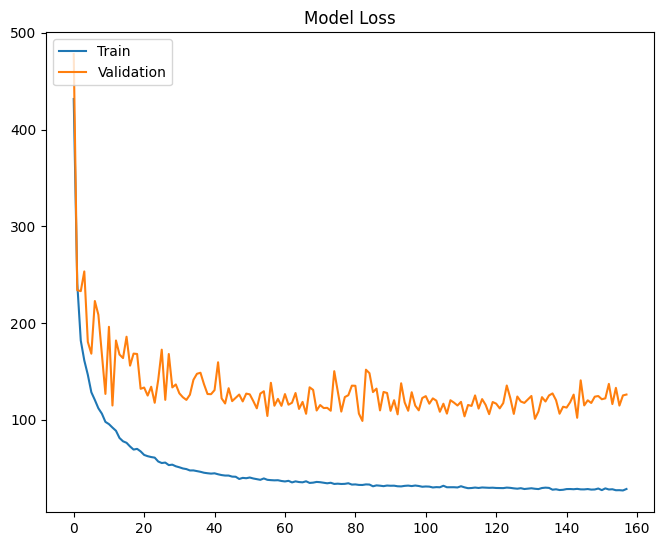

In [40]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.xlabel=('Epoch')
plt.ylabel=('Loss')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

##Plotting sex accuracy

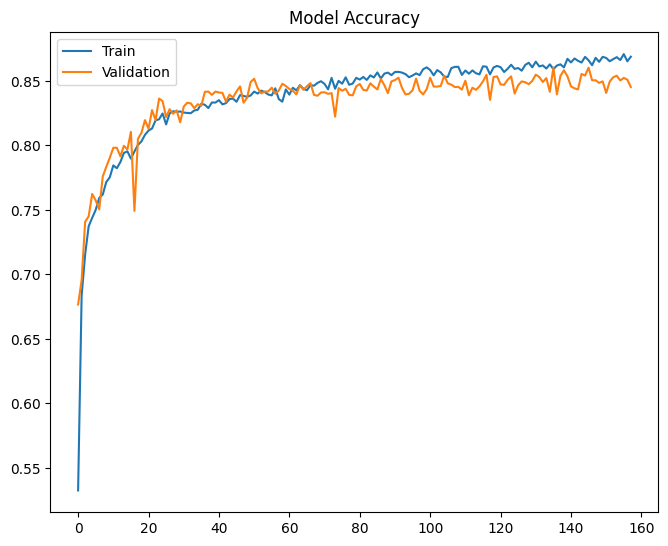

In [41]:
plt.plot(History.history['sex_out_accuracy'])
plt.plot(History.history['val_sex_out_accuracy'])
plt.title('Model Accuracy')
plt.xlabel=('Epoch')
plt.ylabel=('Accuracy')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

##Plotting gender Accuracy

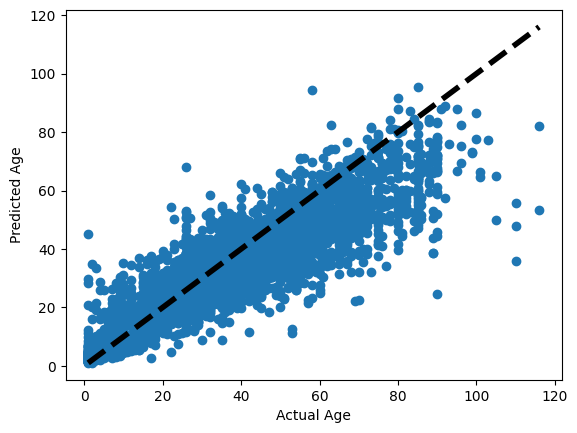

In [42]:
fig,ax=plt.subplots()
ax.scatter(Y_test_2[1],pred[1])
ax.plot([Y_test_2[1].min(),Y_test_2[1].max()],[Y_test_2[1].min(),Y_test_2[1].max()],'k--',lw=4)
ax.set_xlabel('Actual Age')
ax.set_ylabel('Predicted Age')
plt.show()

##Making Report of the model (gender only)

In [43]:
i=0
Pred_1=[]
while(i<len(pred[0])):
    Pred_1.append(int(np.round(pred[0][i])))
    i=i+1

C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1451905169.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Pred_1.append(int(np.round(pred[0][i])))


In [44]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [45]:
report=classification_report(Y_test_2[0],Pred_1)

In [46]:
print(report)

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      3145
           1       0.80      0.89      0.84      2782

    accuracy                           0.84      5927
   macro avg       0.84      0.85      0.84      5927
weighted avg       0.85      0.84      0.84      5927



##Making Heatmap of the model(gender only)

In [47]:
results=confusion_matrix(Y_test_2[0],Pred_1)

<Axes: >

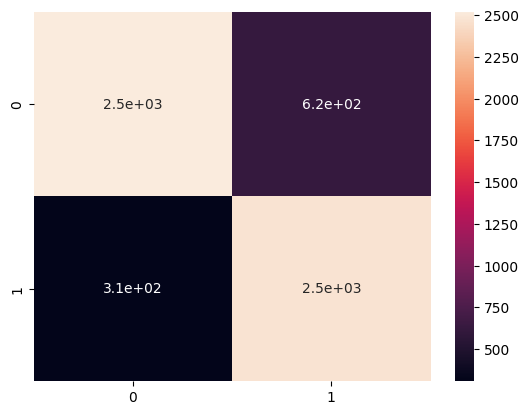

In [48]:
import seaborn as sns
sns.heatmap(results,annot=True)

Testing the images Ourself

In [49]:
def test_image(ind,images_f,images_f_2,Model):
    plt.imshow(images_f[ind])
    image_test=images_f_2[ind]
    pred_1=Model.predict(np.array([image_test]))
    sex_f=['Male','Female']
    age=int(np.round(pred_1[1][0]))
    sex=int(np.round(pred_1[0][0]))
    print("Predicted Age is"+ str(age))
    print("Predicted Gender is"+ sex_f[sex])

##Test 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Age is87
Predicted Gender isFemale


C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_1[1][0]))
C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_1[0][0]))


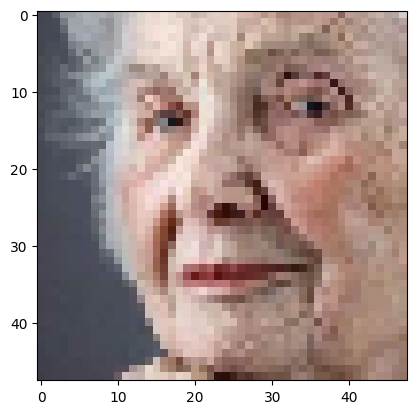

In [50]:
test_image(4,images_f,images_f_2,Model)

##Test 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Age is14
Predicted Gender isFemale


C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_1[1][0]))
C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_1[0][0]))


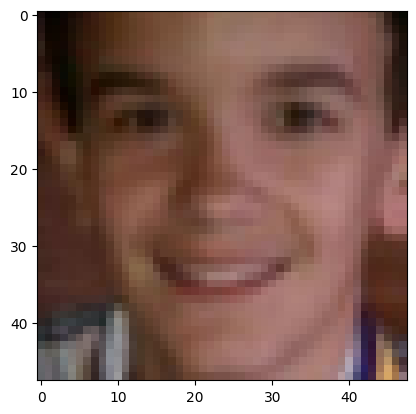

In [51]:
test_image(23,images_f,images_f_2,Model)

##Test 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Age is10
Predicted Gender isFemale


C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_1[1][0]))
C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_1[0][0]))


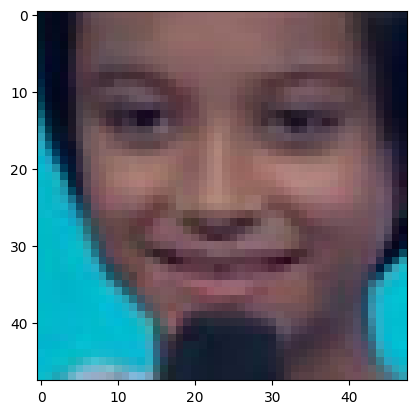

In [52]:
test_image(168,images_f,images_f_2,Model)

##Test 4 (error in age in this case)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Age is18
Predicted Gender isMale


C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_1[1][0]))
C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_1[0][0]))


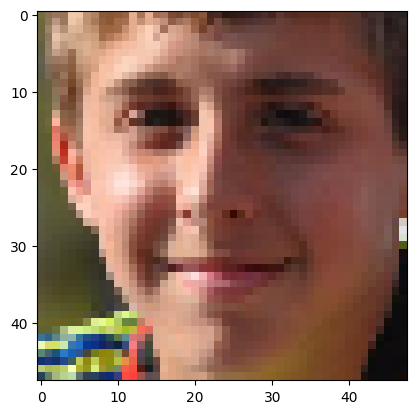

In [53]:
test_image(888,images_f,images_f_2,Model)

##Test 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Age is23
Predicted Gender isFemale


C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  age=int(np.round(pred_1[1][0]))
C:\Users\Sanskruti\AppData\Local\Temp\ipykernel_18188\1900679641.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sex=int(np.round(pred_1[0][0]))


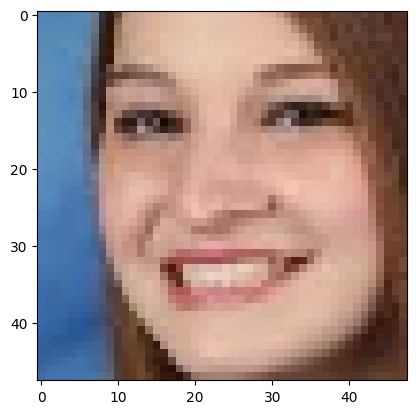

In [54]:
test_image(1288,images_f,images_f_2,Model)